# **병합, MICE**

In [1]:
# 0. 라이브러리 불러오기
from google.colab import files
import pandas as pd

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. 7개 CSV 파일 업로드
print("7개 CSV 파일을 모두 선택해서 업로드하세요.")
uploaded = files.upload()

print("\n업로드된 파일 목록:")
for fname in uploaded.keys():
    print("-", fname)

# 2. 공통 key 기준으로 병합 (Country Name, Country Code, Year)
key_cols = ['Country Name', 'Country Code', 'Year']

merged_df = None

for fname in uploaded.keys():
    print("병합 중 →", fname)
    df = pd.read_csv(fname)

    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, on=key_cols, how='outer')

print("\n ✅ 병합 완료, 데이터 크기:", merged_df.shape)
display(merged_df.head())

# 3. 분석에 사용할 7개 변수 이름 지정
target_cols = [
    'Percentage of Underweight Children',
    'Prevelance of Underweight among Adults',
    'GDP per capita',
    'Govt. Health Expenditure',
    'Maternal Mortality Ratio',
    'Mean age of women at first birth',
    'School enrollment rate, secondary, female'
]

print("\n사용할 타겟 변수들:")
for c in target_cols:
    print("-", c)

# 4. 하나의 열(missing_flag) 만들기
#    - 7개 변수 중 하나라도 NaN 있으면 0
#    - 7개 모두 값이 있으면 1
#    (* MICE 적용 전에 만들어야 '원래 결측이었는지' 알 수 있음)
merged_df['missing_flag'] = (merged_df[target_cols].isna().sum(axis=1) == 0).astype(int)

print("\nmissing_flag 값 분포 (0=결측 있음, 1=결측 없음):")
print(merged_df['missing_flag'].value_counts())

display(merged_df[target_cols + ['missing_flag']].head())

# 5. MICE(IterativeImputer)로 7개 변수의 결측값 채우기
imputer = IterativeImputer(max_iter=10, random_state=42)

print("\n🔧 MICE로 결측값 채우는 중...")
merged_df[target_cols] = imputer.fit_transform(merged_df[target_cols])

print("✅ MICE 완료.")

# 6. 결측치 다시 확인 (7개 지표는 이제 NaN 없어야 함)
print("\n각 타겟 변수별 남은 결측치 수:")
print(merged_df[target_cols].isna().sum())

display(merged_df.head())

# 7. 최종 결과 저장
output_name = "final_merged_mice_with_missing_flag.csv"
merged_df.to_csv(output_name, index=False)

print("\n💾 최종 파일 저장 완료:", output_name)

7개 CSV 파일을 모두 선택해서 업로드하세요.


Saving 1. Percentage-of-underweight-children-data.csv to 1. Percentage-of-underweight-children-data.csv
Saving 4. Domestic general government health expenditure ( of GDP).csv to 4. Domestic general government health expenditure ( of GDP).csv
Saving 5. Maternal Mortality Ratio.csv to 5. Maternal Mortality Ratio.csv
Saving 2. Prevalence of Underweight among Female Adults (Age Standardized Estimate).csv to 2. Prevalence of Underweight among Female Adults (Age Standardized Estimate).csv
Saving 3. GDP per capita (Constant 2015 US).csv to 3. GDP per capita (Constant 2015 US).csv
Saving 6. Mean-age-at-first-birth-of-women-aged-20-50-data.csv to 6. Mean-age-at-first-birth-of-women-aged-20-50-data.csv
Saving 7. School enrollment secondary female ( gross).csv to 7. School enrollment secondary female ( gross).csv

업로드된 파일 목록:
- 1. Percentage-of-underweight-children-data.csv
- 4. Domestic general government health expenditure ( of GDP).csv
- 5. Maternal Mortality Ratio.csv
- 2. Prevalence of Under

,Country Name,Continent_x,Country Code,Year,Percentage of Underweight Children,Govt. Health Expenditure,Maternal Mortality Ratio,Prevelance of Underweight among Adults,GDP per capita,Continent_y,Mean age of women at first birth,"School enrollment rate, secondary, female"
0,Afghanistan,NaN,AFG,2011,NaN,0.480000,884.0,17.6,551.000624,Asia/Pacific,18.9,36.635960
1,Afghanistan,NaN,AFG,2012,NaN,0.342887,833.0,17.3,596.442440,Asia/Pacific,19.1,38.107941
2,Afghanistan,NaN,AFG,2013,NaN,0.443359,821.0,16.9,608.386332,Asia/Pacific,19.2,37.848492
3,Afghanistan,NaN,AFG,2014,NaN,0.472657,785.0,16.6,602.516600,Asia/Pacific,19.3,37.332989
4,Afghanistan,NaN,AFG,2015,NaN,0.522673,776.0,16.2,592.476165,Asia/Pacific,19.4,36.751850



사용할 타겟 변수들:
- Percentage of Underweight Children
- Prevelance of Underweight among Adults
- GDP per capita
- Govt. Health Expenditure
- Maternal Mortality Ratio
- Mean age of women at first birth
- School enrollment rate, secondary, female

missing_flag 값 분포 (0=결측 있음, 1=결측 없음):
missing_flag
0    1613
1     241
Name: count, dtype: int64


,Percentage of Underweight Children,Prevelance of Underweight among Adults,GDP per capita,Govt. Health Expenditure,Maternal Mortality Ratio,Mean age of women at first birth,"School enrollment rate, secondary, female",missing_flag
0,NaN,17.6,551.000624,0.480000,884.0,18.9,36.635960,0
1,NaN,17.3,596.442440,0.342887,833.0,19.1,38.107941,0
2,NaN,16.9,608.386332,0.443359,821.0,19.2,37.848492,0
3,NaN,16.6,602.516600,0.472657,785.0,19.3,37.332989,0
4,NaN,16.2,592.476165,0.522673,776.0,19.4,36.751850,0



🔧 MICE로 결측값 채우는 중...
✅ MICE 완료.

각 타겟 변수별 남은 결측치 수:
Percentage of Underweight Children           0
Prevelance of Underweight among Adults       0
GDP per capita                               0
Govt. Health Expenditure                     0
Maternal Mortality Ratio                     0
Mean age of women at first birth             0
School enrollment rate, secondary, female    0
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,Country Name,Continent_x,Country Code,Year,Percentage of Underweight Children,Govt. Health Expenditure,Maternal Mortality Ratio,Prevelance of Underweight among Adults,GDP per capita,Continent_y,Mean age of women at first birth,"School enrollment rate, secondary, female",missing_flag
0,Afghanistan,NaN,AFG,2011,32.038898,0.480000,884.0,17.6,551.000624,Asia/Pacific,18.9,36.635960,0
1,Afghanistan,NaN,AFG,2012,31.289927,0.342887,833.0,17.3,596.442440,Asia/Pacific,19.1,38.107941,0
2,Afghanistan,NaN,AFG,2013,30.803204,0.443359,821.0,16.9,608.386332,Asia/Pacific,19.2,37.848492,0
3,Afghanistan,NaN,AFG,2014,30.358881,0.472657,785.0,16.6,602.516600,Asia/Pacific,19.3,37.332989,0
4,Afghanistan,NaN,AFG,2015,29.927223,0.522673,776.0,16.2,592.476165,Asia/Pacific,19.4,36.751850,0



💾 최종 파일 저장 완료: final_merged_mice_with_missing_flag.csv


## 결과 해석

- 7개 데이터 공통 키: Country Name / Country Code / Year 기준으로 병합

- 최종적으로 포함된 7개 주요 변수
    1. Percentage of Underweight Children
    2. Prevelance of Underweight among Adults
    3. GDP per capita
    4. Govt. Health Expenditure
    5. Maternal Mortality Ratio
    6. Mean age of women at first birth
    7. School enrollment rate, secondary, female

- missing_flag 컬럼
    - 0: 7개 지표 중 하나라도 결측이 있었던 행
    - 1: 7개 지표 모두 값이 있었던 행

- MICE 적용 후 (데이터의 다른 변수들을 이용해 결측값을 채워주는 대체 방법)
    - 7개 모두 결측치(Nan) = 0개

- 최종 파일: final_merged_mice_with_missing_flag.csv


# **EDA**

In [2]:
# 데이터 불러오기

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_merged_mice_with_missing_flag.csv")
df.head()

,Country Name,Continent_x,Country Code,Year,Percentage of Underweight Children,Govt. Health Expenditure,Maternal Mortality Ratio,Prevelance of Underweight among Adults,GDP per capita,Continent_y,Mean age of women at first birth,"School enrollment rate, secondary, female",missing_flag
0,Afghanistan,NaN,AFG,2011,32.038898,0.480000,884.0,17.6,551.000624,Asia/Pacific,18.9,36.635960,0
1,Afghanistan,NaN,AFG,2012,31.289927,0.342887,833.0,17.3,596.442440,Asia/Pacific,19.1,38.107941,0
2,Afghanistan,NaN,AFG,2013,30.803204,0.443359,821.0,16.9,608.386332,Asia/Pacific,19.2,37.848492,0
3,Afghanistan,NaN,AFG,2014,30.358881,0.472657,785.0,16.6,602.516600,Asia/Pacific,19.3,37.332989,0
4,Afghanistan,NaN,AFG,2015,29.927223,0.522673,776.0,16.2,592.476165,Asia/Pacific,19.4,36.751850,0


In [3]:
# 데이터 기본 구조 확인

df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country Name                               1854 non-null   object 
 1   Continent_x                                666 non-null    object 
 2   Country Code                               1854 non-null   object 
 3   Year                                       1854 non-null   int64  
 4   Percentage of Underweight Children         1854 non-null   float64
 5   Govt. Health Expenditure                   1854 non-null   float64
 6   Maternal Mortality Ratio                   1854 non-null   float64
 7   Prevelance of Underweight among Adults     1854 non-null   float64
 8   GDP per capita                             1854 non-null   float64
 9   Continent_y                                690 non-null    object 
 10  Mean age of women at fir

,count,mean,std,min,25%,50%,75%,max
Year,1854.0,2013.500000,1.708286,2011.000000,2012.000000,2013.500000,2015.000000,2016.000000
Percentage of Underweight Children,1854.0,14.585570,11.594617,-6.881718,6.593320,12.281648,20.322190,104.630080
Govt. Health Expenditure,1854.0,3.352738,2.096102,-1.289202,1.715663,3.133686,4.405577,12.081347
Maternal Mortality Ratio,1854.0,176.276639,222.374682,-540.444978,20.000000,85.000000,250.954488,1288.000000
Prevelance of Underweight among Adults,1854.0,5.749118,4.266092,-7.762367,2.500000,4.680583,8.300000,26.000000
GDP per capita,1854.0,14278.790904,19854.538455,-6204.699354,2234.900229,7348.389880,16925.413697,174739.577800
Mean age of women at first birth,1854.0,22.177535,2.390985,17.316011,20.680541,22.027520,23.096183,36.403642
"School enrollment rate, secondary, female",1854.0,80.555252,26.583558,-16.074511,65.970629,86.893754,98.471510,175.383626
missing_flag,1854.0,0.129989,0.336382,0.000000,0.000000,0.000000,0.000000,1.000000


In [4]:
# 결측치 확인

df.isna().sum()

,0
Country Name,0
Continent_x,1188
Country Code,0
Year,0
Percentage of Underweight Children,0
Govt. Health Expenditure,0
Maternal Mortality Ratio,0
Prevelance of Underweight among Adults,0
GDP per capita,0
Continent_y,1164


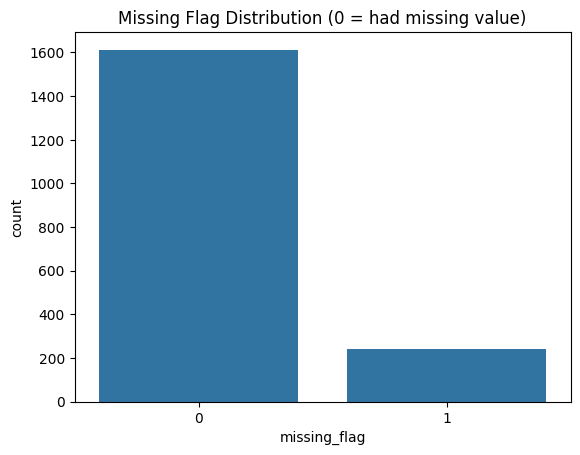

In [5]:
# missing_flag 의미 분석
# misising_flag: 원래 결측이 있었는지 여부를 나타냄

df['missing_flag'].value_counts()

sns.countplot(data=df, x='missing_flag')
plt.title("Missing Flag Distribution (0 = had missing value)")
plt.show()

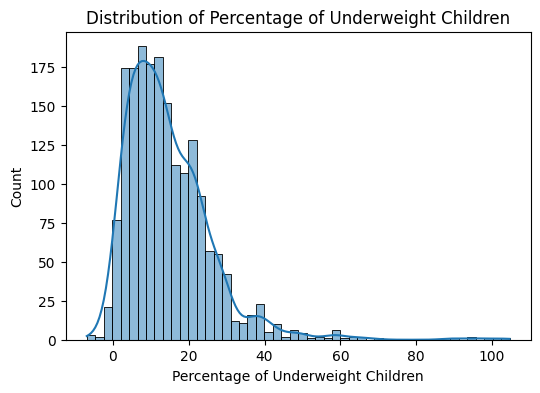

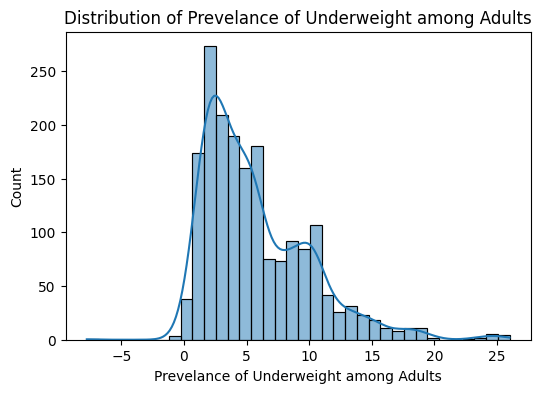

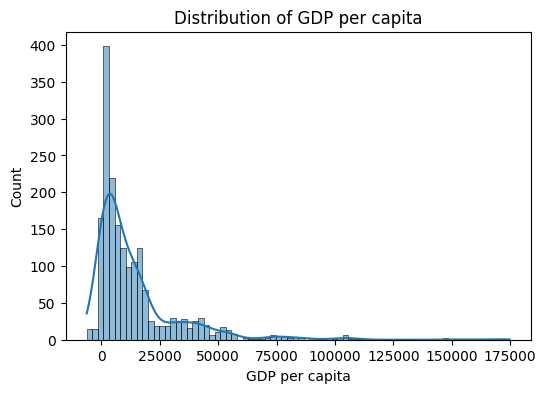

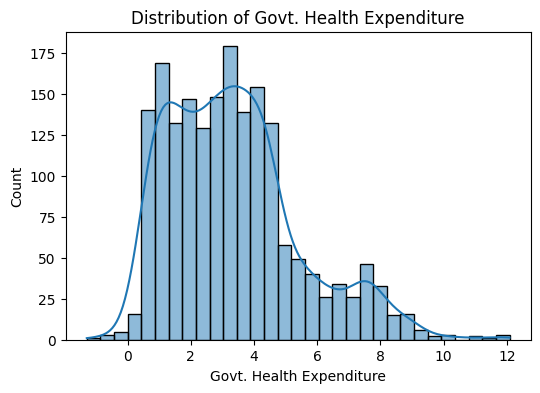

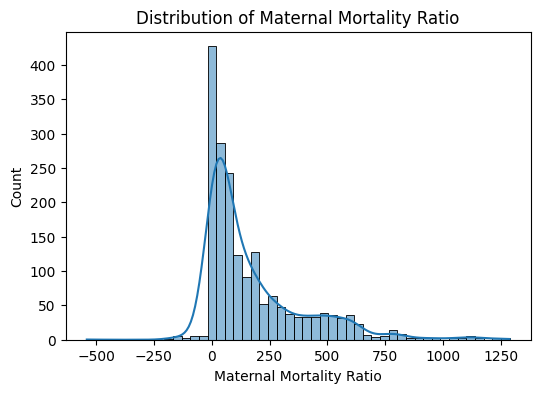

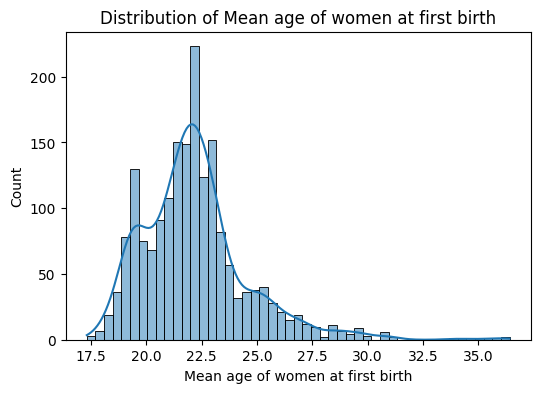

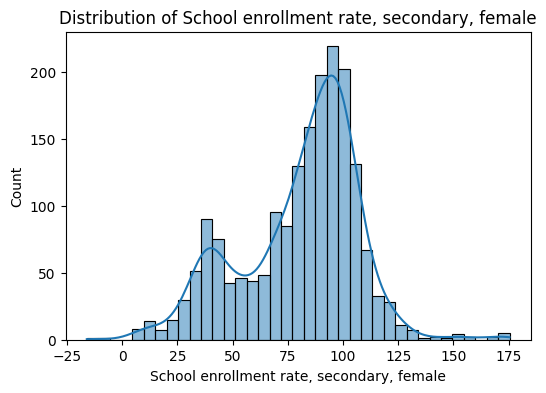

In [7]:
# 변수 분포 확인 (왜도, 로그 변환 필요성 판단)

for col in [
    'Percentage of Underweight Children',
    'Prevelance of Underweight among Adults',
    'GDP per capita',
    'Govt. Health Expenditure',
    'Maternal Mortality Ratio',
    'Mean age of women at first birth',
    'School enrollment rate, secondary, female'
]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### 히스토그램 해석

5. Maternal Mortality Ratio (모성 사망률)

- 심각한 오른쪽 꼬리 분포

- 대부분 국가는 사망률이 낮지만
일부 저개발 국가에서 매우 높은 값(500~1200) 존재

➡ 로그 변환이 가장 필요한 변수 중 하나

6. Mean age of women at first birth (초산 연령)

- 비교적 정상적인 분포

- 20~23세 근처에 집중되어 있고 천천히 퍼져 있음

- 극단값(30세 이상)은 소수

➡ 변환 필요 없음

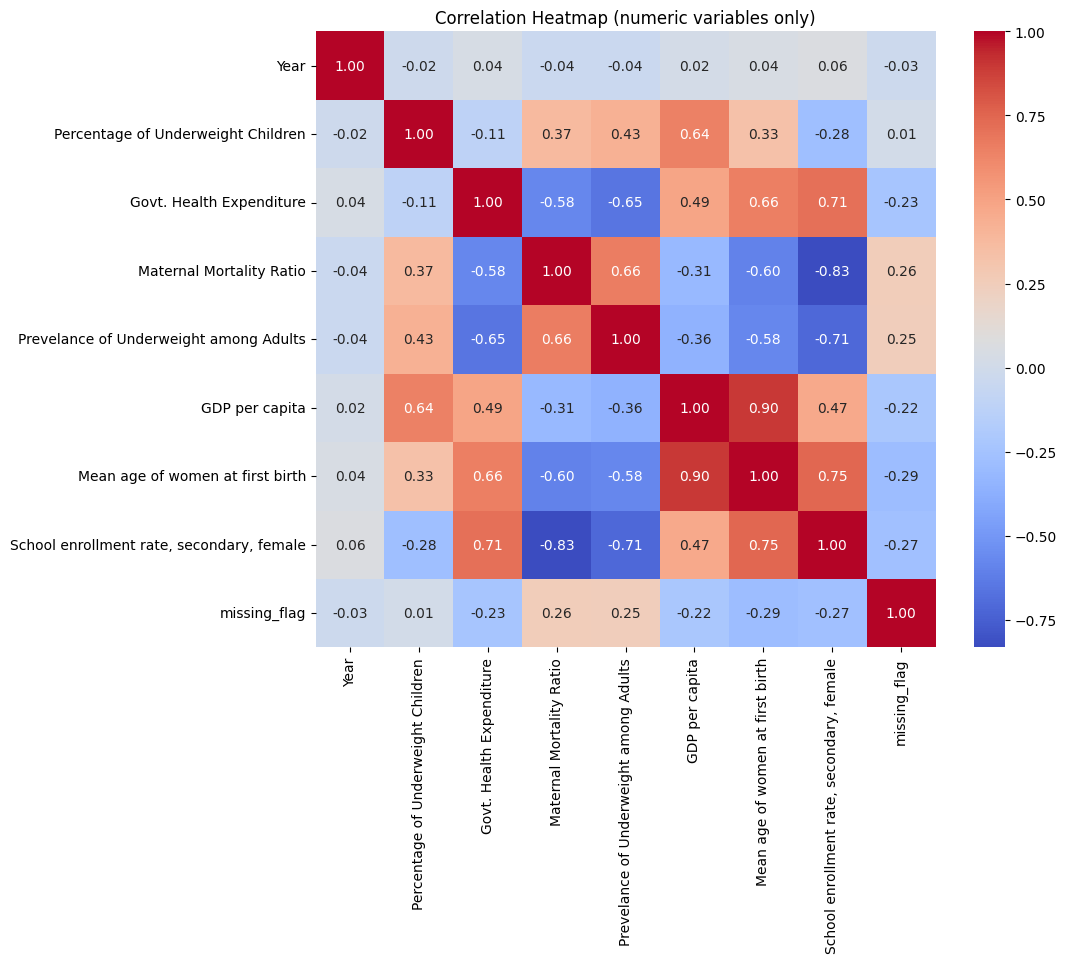

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 숫자형 컬럼만 선택
num_df = df.select_dtypes(include=['int64', 'float64'])

# 2) 상관계수 계산
corr = num_df.corr()

# 3) heatmap 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap (numeric variables only)")
plt.show()

### 히트맵 결과 해석

1. 경제 수준(GDP)이 가장 중요한 변수
    - GDP가 높을수록
    - 아동 영양 개선
    - 여성의 초산 연령 증가
    - 보건 지출 증가
    - 여학생 중등 취학률 증가

2. 여성 교육 지표의 영향력 매우 큼
    - 여학생의 취확률은
    - 모성 사망률과 가장 강한 음의 상관(-0.83)
    - 초산 연령과도 높은 양의 상관(0.75)

3. 보건 지출도 교육, 경제와 함께 움직임
    - 보건 지출은 GDP, 초산 연령, 교육 지표와 모두 양의 상관
    - → 경제 성장 → 보건 투자 증가 → 건강 지표 개선이라는 구조적 흐름이 보임

4. 아동, 성인 영양실조는 구조적 요인과 함께 나타남
    - 아동 체중 미달률은
    - GDP와 중간 정도 음의 상관(-0.64)
    - 성인 여성 영양실조와도 양의 상관(0.43)
    